# Binary orbit

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.models import KeplerModel
from exogaia.results import SamplingResults
from exogaia.samplers import MCMCSampler, NestedSampler

In [3]:
np.random.seed(42)

## Gaia epoch astrometry

The ``EpochAstrometry`` class is used for storing Gaia epoch astrometry. For now, we can simulate epoch astrometry for Gaia DR4 or DR5. To do so, we can either set the stellar parameters manually or retrieve parameters from DR3.

In this example, we simulate a binary system by manually providing the stellar parameters. We choose a relatively small orbit such that most of the phase is well sampled by the simulated measurements.

In [4]:
primary_mass = (1.0, 0.1)  # (Msun)

In [5]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR4')


----------------
Epoch astrometry
----------------

Gaia release: DR4
Reference epoch: 2017.5

Primary mass (Msun): 1.00 +/- 0.10


In [6]:
mass_2 = 10.0  # (Mjup)
sma, ecc, inc, aop, pan, tau = 2., 0.3, np.radians(60.0), np.radians(40.0), np.radians(90.0), 0.5
ra, dec, parallax, pmra, pmdec, phot_g_mean_mag = 50.0, 20.0, 25.0, -30.0, 30.0, 7.0

In [7]:
model_param = epoch_astrom.simulate_data(mass_2=mass_2, sma=sma, ecc=ecc, inc=inc, aop=aop, pan=pan, tau=tau,
                                         ra=ra, dec=dec, parallax=parallax, pmra=pmra, pmdec=pmdec, phot_g_mean_mag=phot_g_mean_mag)


-------------
Simulate data
-------------

System type: binary

AL scan uncertainty (per CCD) = 159.98 uas
AL scan uncertainty (per transit) = 56.56 uas

Stellar parameters:
   - RA (deg) = 50.00
   - Dec (deg) = 20.00
   - Parallax (mas) = 25.00
   - Proper motion in RA (mas/yr) = -30.00
   - Proper motion in Dec (mas/yr) = 30.00
   - G-band magnitude = 7.00

Orbit parameters:
   - Primary mass (Msun) = 1.00
   - Companion mass (Mjup) = 10.00
   - Relative semi-major axis (au) = 2.00
   - Eccentricity = 0.30
   - Inclination (deg) = 60.00
   - Argument of periastron (deg) = 40.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.50
   - Period (days) = 1028.19
   - Semi-major axis of photocenter (mas) = 0.47


## Plot the simulated orbit

In [8]:
kepler_model = KeplerModel(epoch_astrometry=epoch_astrom)


-------------------
Calculate residuals
-------------------


---------------------
Calculate orbit model
---------------------

Stellar parameters:
   - RA (deg) = 0.000
   - Dec (deg) = 0.000
   - Parallax (mas) = 25.000
   - Proper motion in RA (mas/yr) = -30.000
   - Proper motion in Dec (mas/yr) = 30.000

Orbit parameters:
   - Period (days) = 1028.187
   - Eccentricity = 0.300
   - Relative time of periastron = 0.500
   - Semi-major axis (mas) = 0.473
   - Inclination (deg) = 60.000
   - Argument of periastron (deg) = 40.000
   - PA of ascending node (deg) = 90.000

Reduced chi^2 = 1.11
RUWE = 1.05

----------
Plot orbit
----------



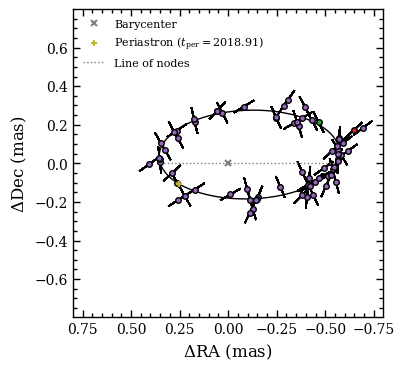

In [9]:
fig = kepler_model.plot_orbit(model_param=model_param, plot_file='plot.png')

## Infer parameters with least-squares

In [10]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Orbit grid (12-parameters)
--------------------------



  0%|          | 0/900 [00:00<?, ?it/s]


Best-fit RUWE = 1.067

Stellar track:
   - RA offset (mas) = 0.055 +/- 0.018
   - Dec offset (mas) = -0.026 +/- 0.012
   - Parallax (mas) = 25.013 +/- 0.015
   - mu in RA (mas/yr) = -30.003 +/- 0.009
   - mu in Dec (mas/yr) = 29.997 +/- 0.006

Thiele-Innes elements:
   - Period (days) = 1082.637
   - Eccentricity = 0.400
   - Relative time of periastron = 0.50
   - Thiele-Innes A = -0.163 +/- 0.014
   - Thiele-Innes B = 0.399 +/- 0.020
   - Thiele-Innes F = -0.159 +/- 0.016
   - Thiele-Innes G = -0.323 +/- 0.021

Derived parameters:
   - Semi-major axis of photocenter (mas) = 0.514 +/- 0.021
   - Relative semi-major axis (au) = 1.691
   - Mass function (Mjup) = 1.035e-03
   - Companion mass (Mjup) = 10.504

Campbell elements:
   - Period = 1082.637 days
   - Eccentricity = 0.400
   - Relative time of periastron = 0.500
   - Semi-major axis of photocenter (mas) = 0.514
   - Inclination (deg) = 63.929
   - Argument of periastron (deg) = 37.367
   - PA of ascending node (deg) = 93.716


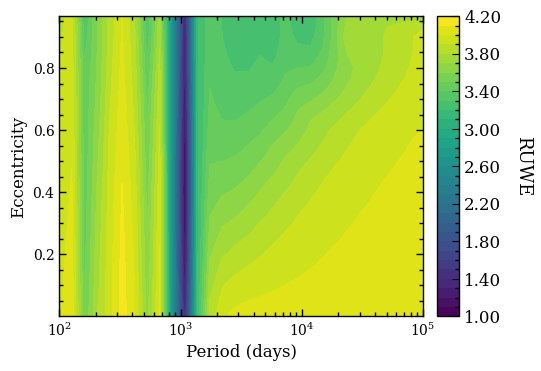

In [11]:
fig = leastsq.orbit_grid(plot_file='plot.png', n_points=30)


-------------------------
Orbit fit (12 parameters)
-------------------------

Number of function evaluations: 7
Number of Jacobian evaluations: 7

Reduced chi^2: 0.426
RUWE: 0.652

Best-fit parameters:
   - RA offset (mas) = 0.045 +/- 0.056
   - Dec offset (mas) = -0.028 +/- 0.026
   - Parallax (mas) = 25.020 +/- 0.015
   - mu in RA (mas/yr) = -29.991 +/- 0.010
   - mu in Dec (mas/yr) = 29.994 +/- 0.006
   - Period (days) = 1043.059 +/- 10.470
   - Eccentricity = 0.383 +/- 0.071
   - Relative time of periastron = 0.502 +/- 0.024
   - Semi-major axis (mas) = 0.508 +/- 0.023
   - Inclination (deg) = 62.592 +/- 2.412
   - Argument of periastron (deg) = 39.303 +/- 9.916
   - PA of ascending node (deg) = 92.472 +/- 2.333


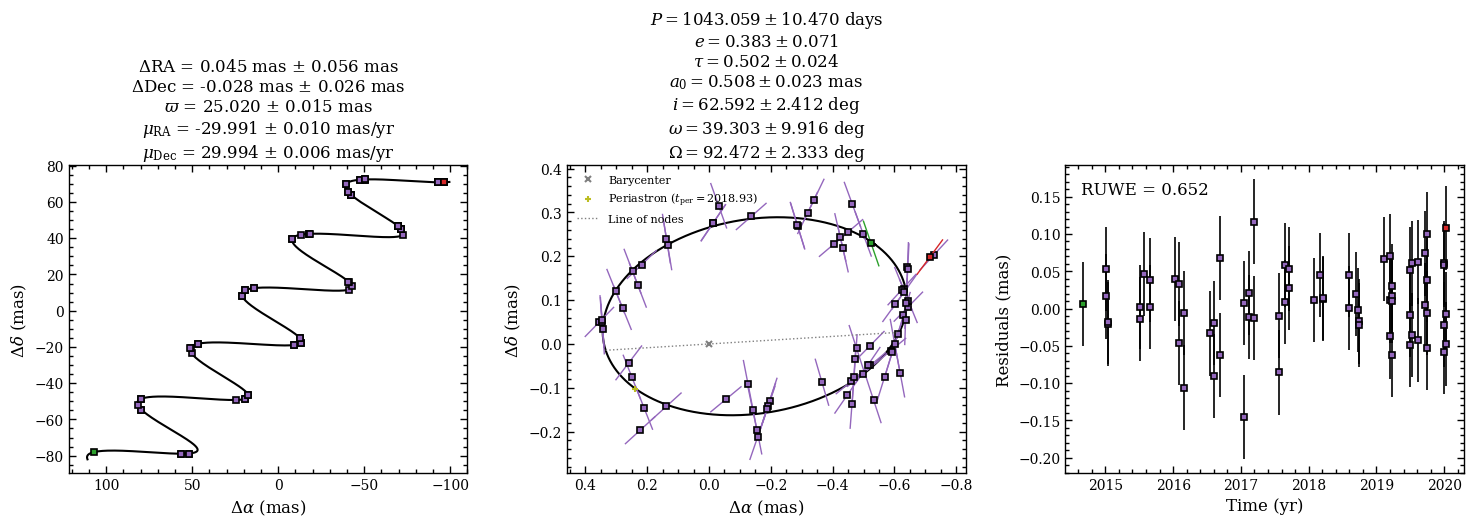

In [12]:
fig = leastsq.orbit_fit(inc_jitter=False, plot_file='plot.png')

In [13]:
print(leastsq)

LeastSquares(Δα = 0.0446332 mas, Δδ = -0.0281183 mas, ϖ = 25.0204 mas, μ_α = -29.9914 mas/yr, μ_δ = 29.9939 mas/yr, P = 1043.06 days, e = 0.383233, τ = 0.502466, a = 0.508235 mas, i = 1.09244 rad, ω = 0.685971 rad, Ω = 1.61395 rad)


## Infer parameters with MCMC

In [14]:
sampler = MCMCSampler(epoch_astrometry=epoch_astrom, least_squares=leastsq)
# sampler = NestedSampler(epoch_astrometry=epoch_astrom, least_squares=leastsq)


------------
MCMC sampler
------------



In [15]:
sampler.run_ptmcmc(
    pickle_file='exogaia.pkl',
    n_temps=10,
    n_walkers=200,
    n_steps=1000,
    n_sweeps=1,
    progress=True,
)


-------------
Run reddemcee
-------------



100%|████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [06:35<00:00, 25.30it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [60.23799744 60.39784544 58.59103231 53.98643149 48.42649013 63.64872984
 61.1972301  61.50255766 61.3549091  58.48879892 60.82409421 63.3018077 ]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [59.03968045 61.85019846 57.2509479  57.17130612 52.79983976 62.26387258
 63.2215679  62.92076866 57.05286683 58.53252983 62.80662168 62.92668083]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [62.81104475 62.87127873 61.24021352 55.12502148 55.69779057 60.04004929
 61.6773

## Plot sampling results

In [16]:
results = SamplingResults(burnin=500, pickle_file='exogaia.pkl')


-----------
Fit results
-----------

Number of parameters: 12
Samples shape: (10, 1000, 200, 12)

Burnin: 500
Samples shape: (10, 500, 200, 12)

Reshaped samples: (1000000, 12)



------------
Plot walkers
------------

Number of walkers: 100
Thin value: 1


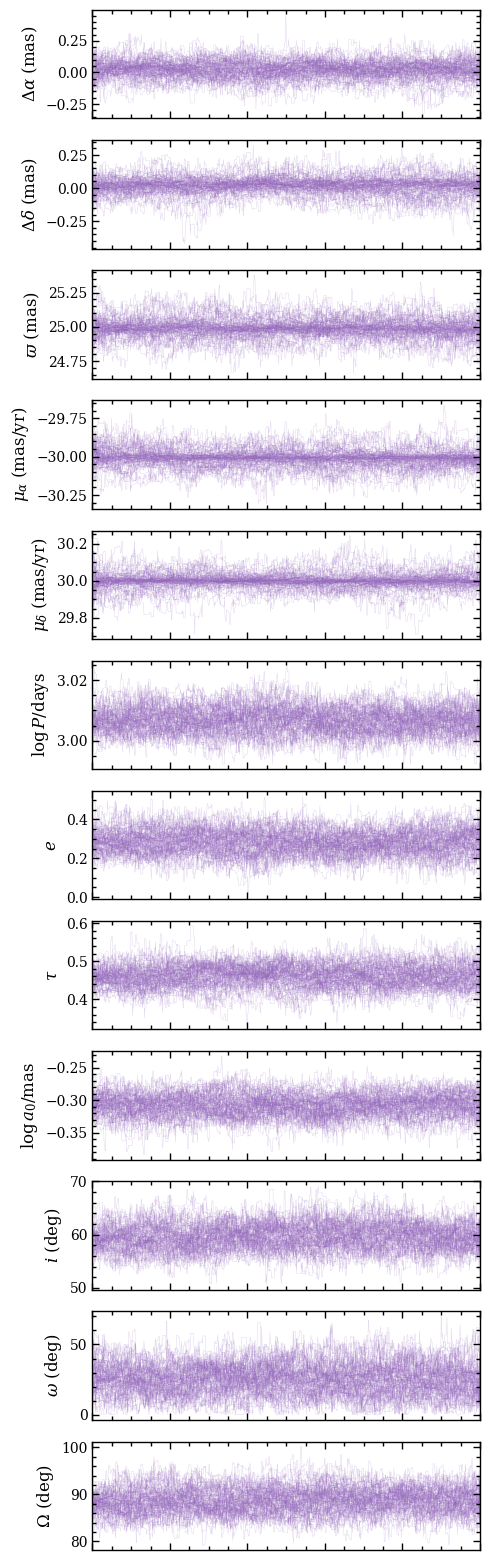

In [17]:
fig = results.plot_walkers(n_walkers=100, thin=None, plot_file=None)


--------------
Plot posterior
--------------

Output file: plot.png


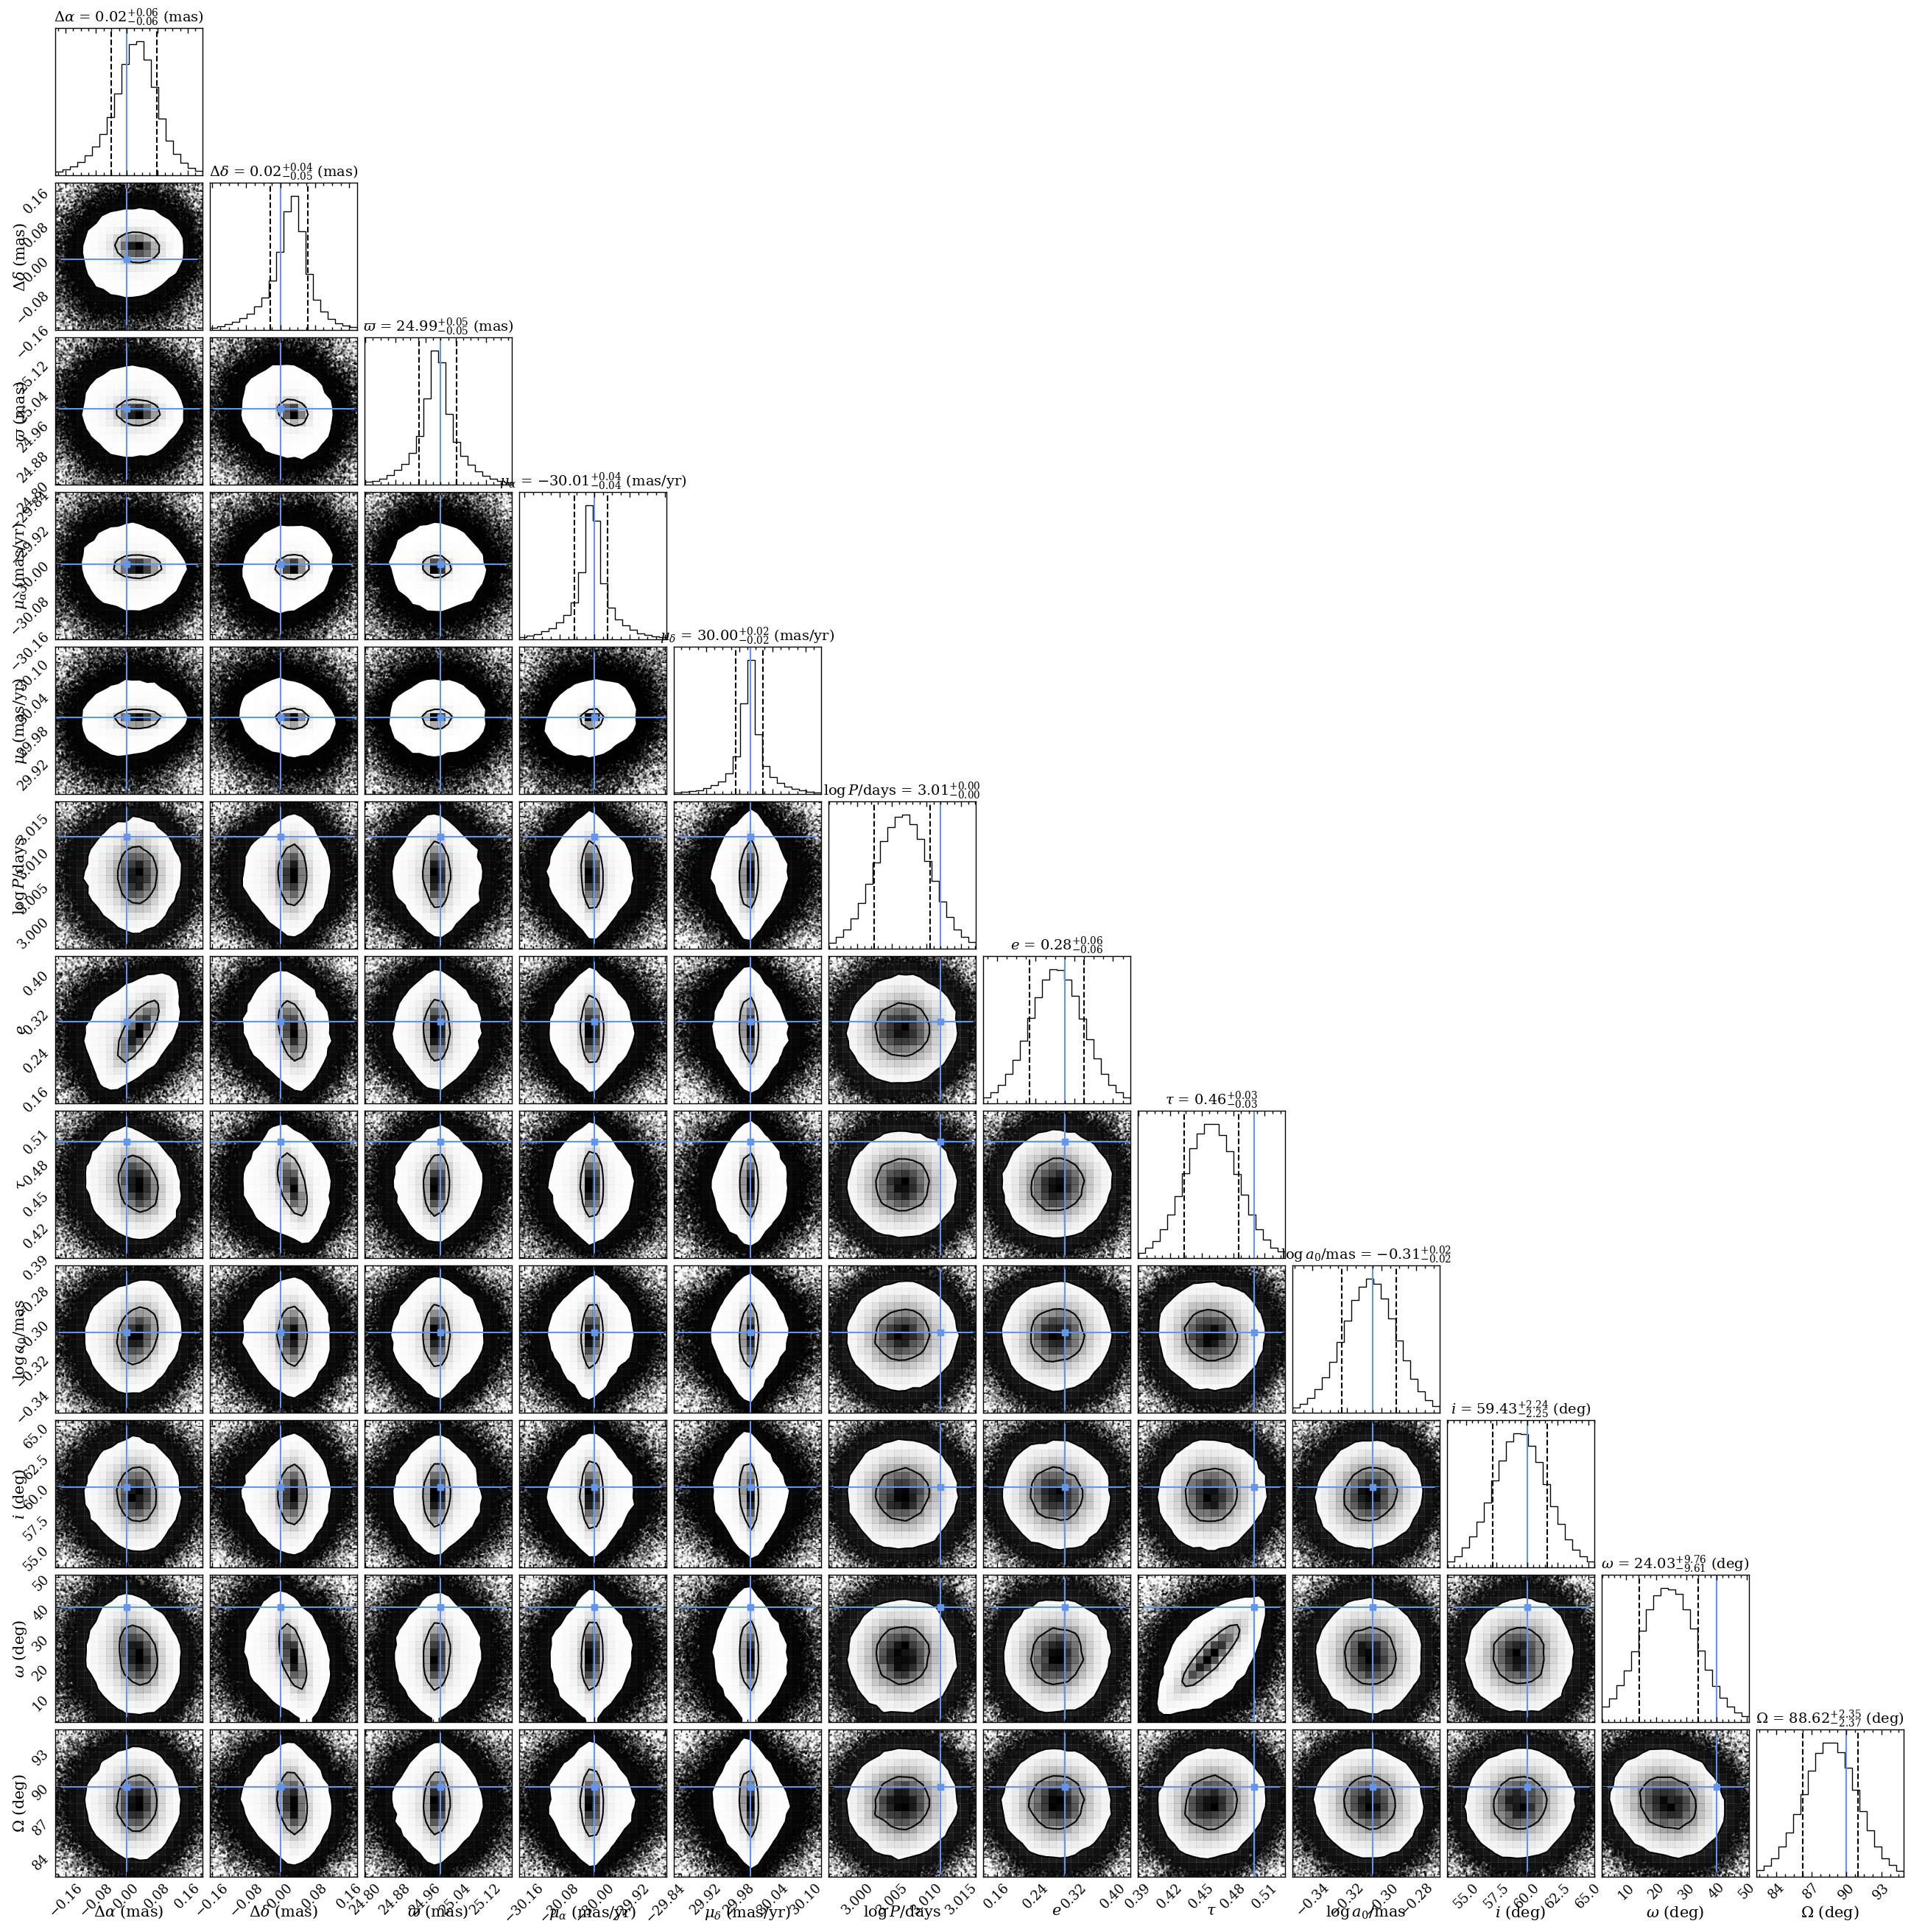

In [18]:
fig = results.plot_posterior(truths=model_param, plot_file='plot.png')


--------------
Plot residuals
--------------


---------------------
Calculate orbit model
---------------------

Stellar parameters:
   - RA (deg) = 0.041
   - Dec (deg) = 0.035
   - Parallax (mas) = 24.990
   - Proper motion in RA (mas/yr) = -30.003
   - Proper motion in Dec (mas/yr) = 30.000

Orbit parameters:
   - Period (days) = 1013.012
   - Eccentricity = 0.284
   - Relative time of periastron = 0.451
   - Semi-major axis (mas) = 0.492
   - Inclination (deg) = 59.207
   - Argument of periastron (deg) = 20.679
   - PA of ascending node (deg) = 89.256


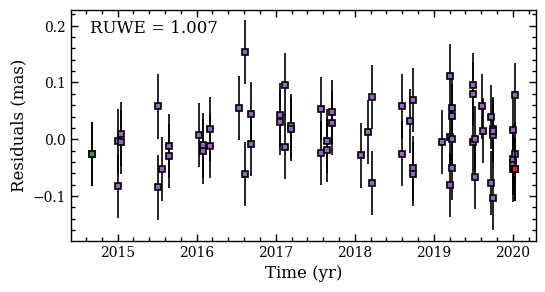

In [19]:
fig = results.plot_residuals(plot_file='plot.png')


----------
Plot orbit
----------



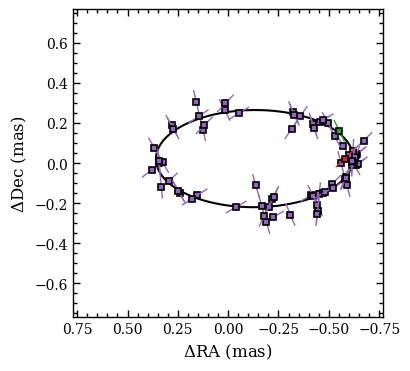

In [20]:
fig = results.plot_orbit(plot_file='plot.png')